In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

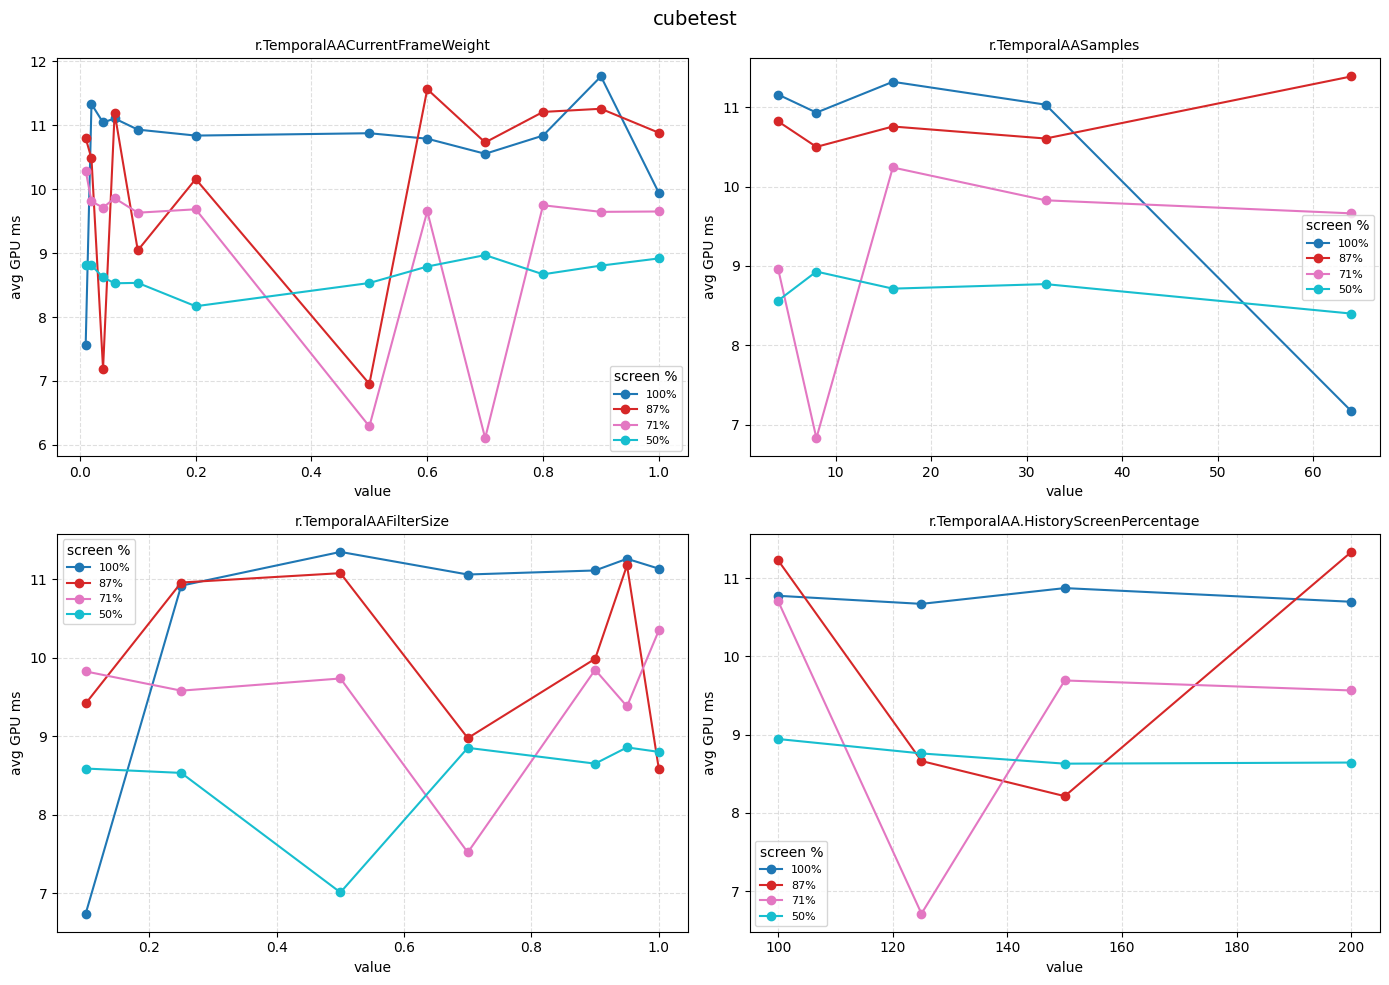

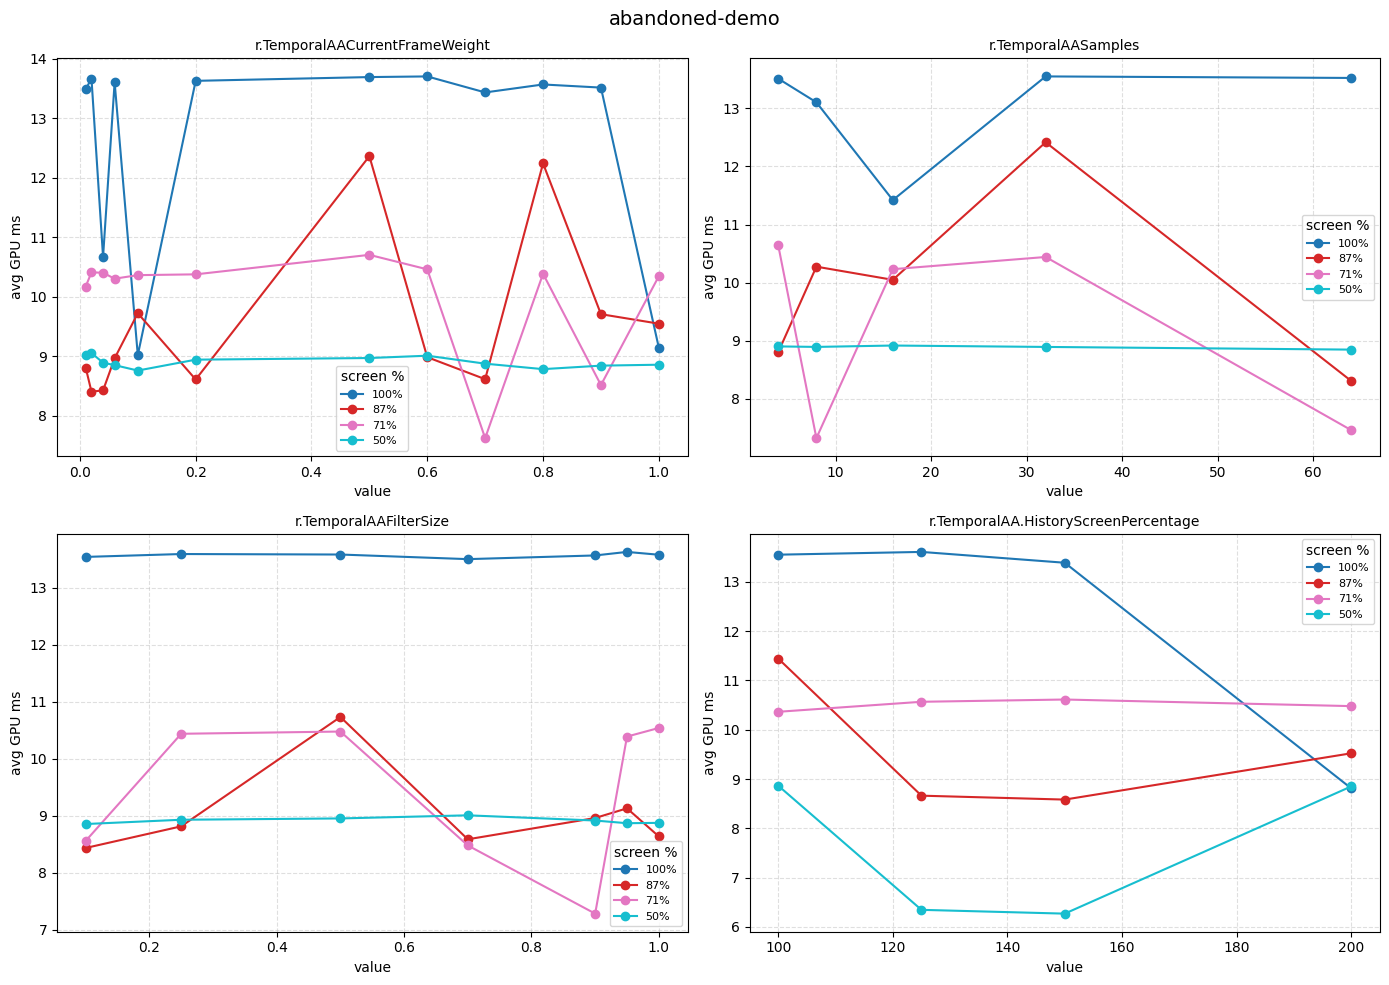

In [10]:
df = pd.read_csv('results.csv')

params = [
    'r.TemporalAACurrentFrameWeight',
    'r.TemporalAASamples',
    'r.TemporalAAFilterSize',
    'r.TemporalAA.HistoryScreenPercentage',
]

for scene in df['scene'].unique():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(scene, fontsize=14)
    axes = axes.flatten()

    for ax, param in zip(axes, params):
        subset = df[(df['scene'] == scene) & (df['cvar_name'] == param)]

        if subset.empty:
            ax.set_title(param)
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            continue

        screen_pcts = sorted(subset['screen_pct'].unique(), reverse=True)
        colors = cm.tab10(np.linspace(0, 1, len(screen_pcts)))

        for color, pct in zip(colors, screen_pcts):
            grp = subset[subset['screen_pct'] == pct].sort_values('cvar_value')
            ax.plot(grp['cvar_value'], grp['avg_gpu_ms'], marker='o', label=f'{pct}%', color=color)

        ax.set_title(param, fontsize=10)
        ax.set_xlabel('value')
        ax.set_ylabel('avg GPU ms')
        ax.legend(title='screen %', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{scene}_all_params.png', dpi=150)
    plt.show()

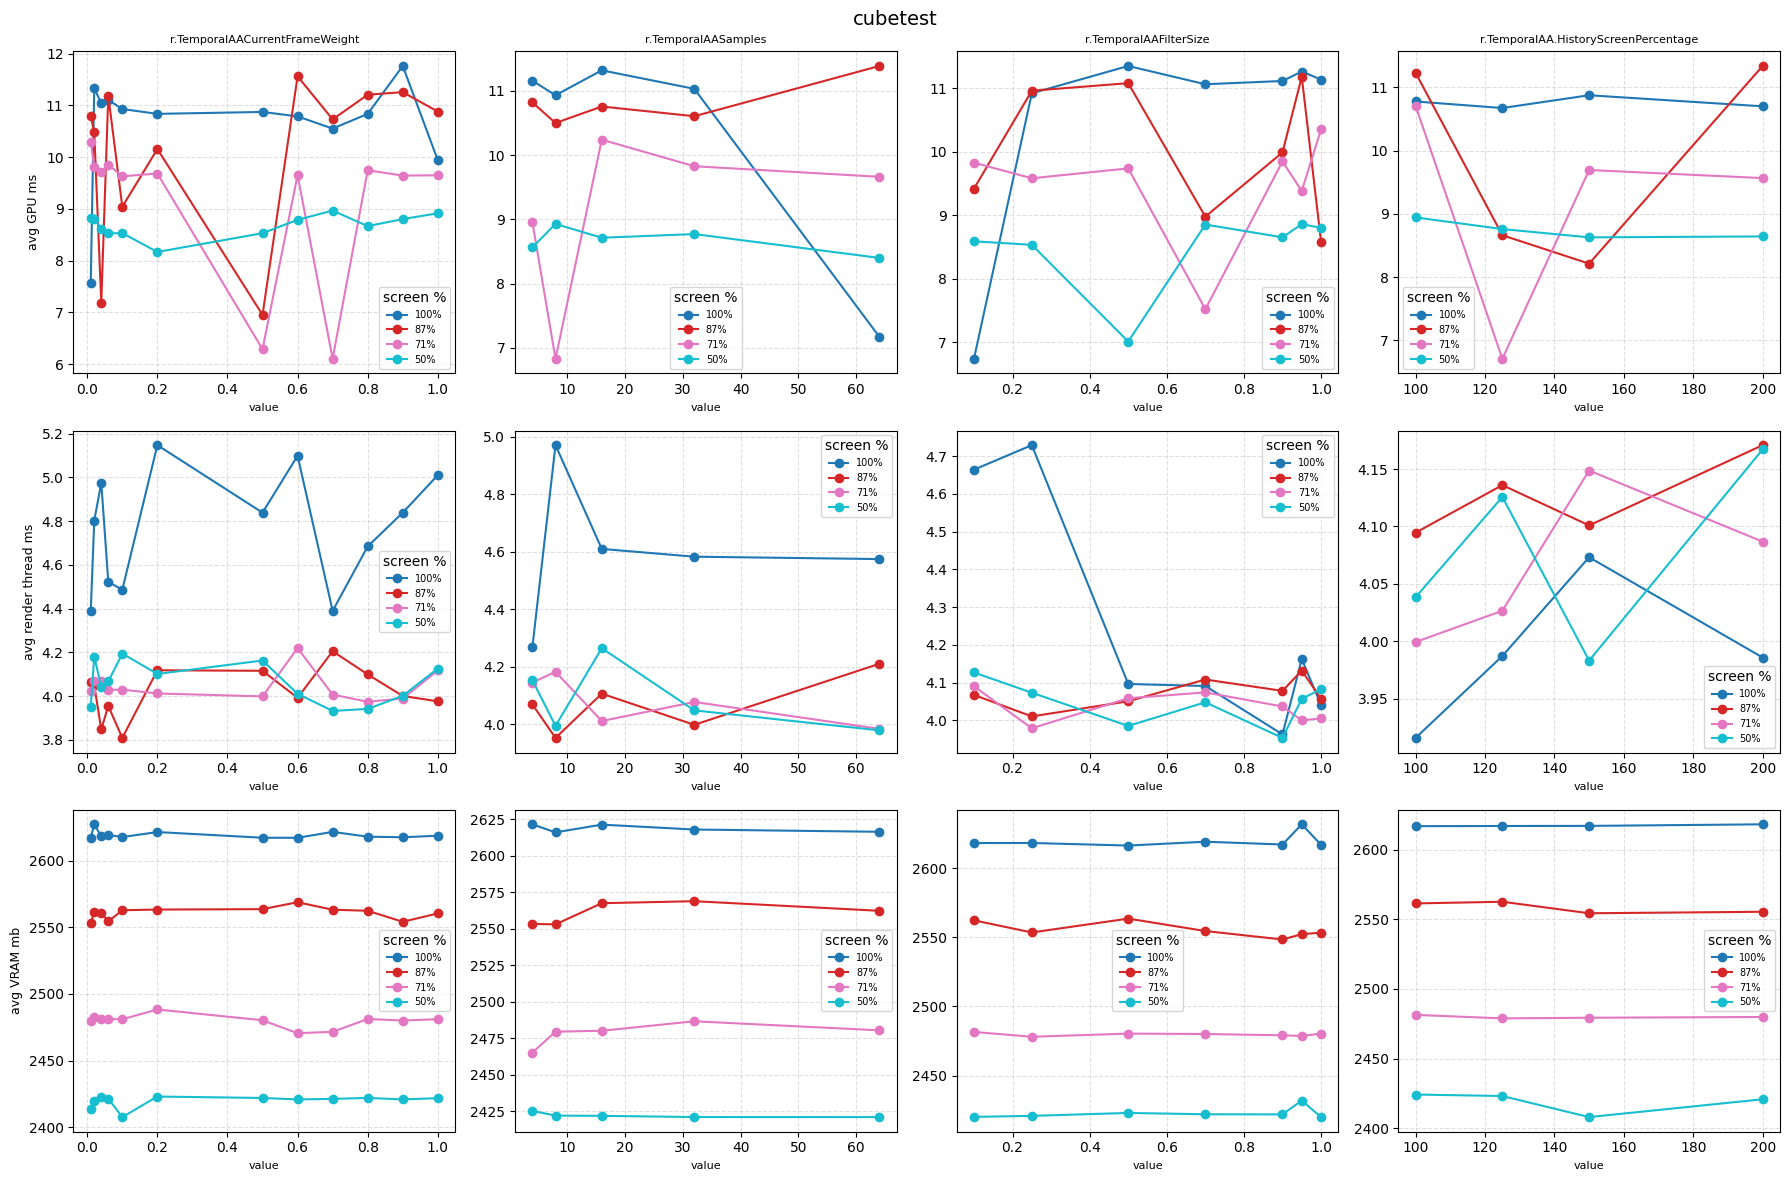

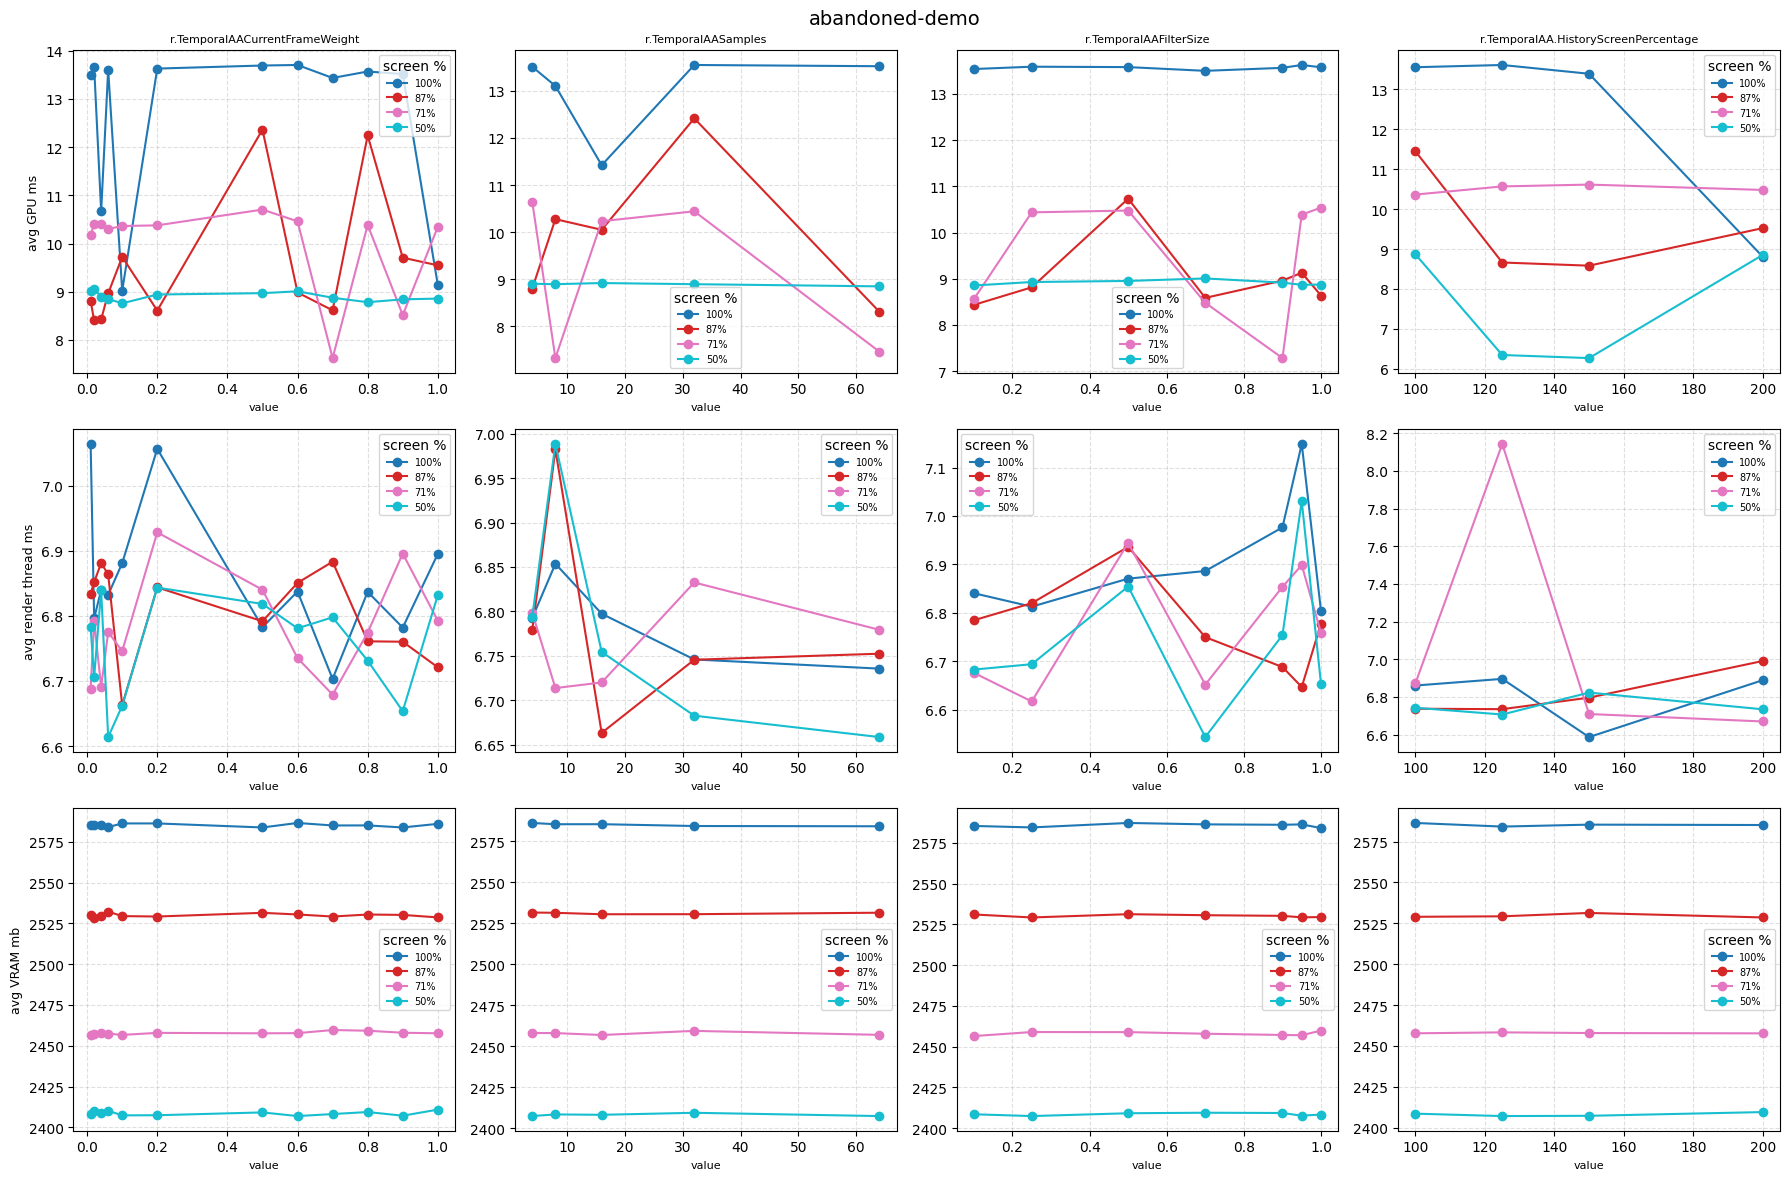

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.read_csv('results.csv')

params = [
    'r.TemporalAACurrentFrameWeight',
    'r.TemporalAASamples',
    'r.TemporalAAFilterSize',
    'r.TemporalAA.HistoryScreenPercentage',
]

metrics = [
    ('avg_gpu_ms',    'avg GPU ms'),
    ('avg_render_ms', 'avg render thread ms'),
    ('avg_mem_mb',    'avg VRAM mb'),
]

for scene in df['scene'].unique():
    fig, axes = plt.subplots(len(metrics), len(params), figsize=(18, 12))
    fig.suptitle(scene, fontsize=14)

    for row, (metric, metric_label) in enumerate(metrics):
        for col, param in enumerate(params):
            ax = axes[row][col]
            subset = df[(df['scene'] == scene) & (df['cvar_name'] == param)]

            if subset.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(param, fontsize=8)
                continue

            screen_pcts = sorted(subset['screen_pct'].unique(), reverse=True)
            colors = cm.tab10(np.linspace(0, 1, len(screen_pcts)))

            for color, pct in zip(colors, screen_pcts):
                grp = subset[subset['screen_pct'] == pct].sort_values('cvar_value')
                ax.plot(grp['cvar_value'], grp[metric], marker='o', label=f'{pct}%', color=color)

            if row == 0:
                ax.set_title(param, fontsize=8)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=9)
            ax.set_xlabel('value', fontsize=8)
            ax.legend(title='screen %', fontsize=7)
            ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{scene}_all_metrics.png', dpi=150)
    plt.show()